NAMA : I GEDE KRISNA YOGA SAPUTRA
NIM 123140163

In [29]:
# ==============================================================================
# IMPORT LIBRARY YANG DIBUTUHKAN
# ==============================================================================
import numpy as np                      # Pustaka untuk operasi array numerik dan manipulasi matriks
import matplotlib.pyplot as plt          # Pustaka untuk membuat grafik dan visualisasi data
import librosa                           # Pustaka utama pemrosesan sinyal audio dan analisis musik
import librosa.display                   # Modul spesifik dari librosa untuk menampilkan visualisasi audio
import scipy.signal                      # Pustaka untuk fungsi pemrosesan sinyal digital (DSP)
import scipy.io.wavfile as wavfile       # Pustaka untuk membaca dan menulis file audio format .wav

# ==============================================================================
# 1. AKUISISI & INSPEKSI METADATA AUDIO
# ==============================================================================

# Menentukan jalur lokasi file audio input yang dimasukkan pengguna
audio_path = 'audio_original.wav'

# Membaca file audio menggunakan librosa.
# Parameter sr=None memastikan laju sampel (sampling rate) asli dari file tidak diubah/diresample otomatis.
# Menghasilkan array sinyal audio (y_orig) dan laju sampelnya (fs_orig).
y_orig, fs_orig = librosa.load(audio_path, sr=None)

# Menghitung durasi audio dalam detik dengan membagi total sampel sinyal dengan laju sampelnya
duration = len(y_orig) / fs_orig

# Menyimpan jumlah total poin data/sampel yang ada di dalam rekaman audio
total_samples = len(y_orig)

# Mengambil nilai amplitudo paling minimum (terrendah) dari seluruh sampel audio
amp_min = np.min(y_orig)

# Mengambil nilai amplitudo paling maksimum (tertinggi) dari seluruh sampel audio
amp_max = np.max(y_orig)

# Menampilkan informasi metadata sinyal audio yang telah dihitung ke konsol
print("--- METADATA AUDIO ASLI ---")
print(f"Laju Sampel Asli (fs) : {fs_orig} Hz")         # Menampilkan frekuensi sampling asli (misal 44100 Hz atau 48000 Hz)
print(f"Durasi Audio          : {duration:.2f} detik")  # Menampilkan durasi rekaman dengan pembulatan 2 desimal
print(f"Total Sampel          : {total_samples} sampel") # Menampilkan jumlah total titik sampel data
print(f"Rentang Amplitudo     : {amp_min:.4f} hingga {amp_max:.4f}") # Menampilkan batas min & max sinyal (ter normalisasi -1 hingga 1)




--- METADATA AUDIO ASLI ---
Laju Sampel Asli (fs) : 44100 Hz
Durasi Audio          : 12.29 detik
Total Sampel          : 541998 sampel
Rentang Amplitudo     : -0.1062 hingga 0.0953


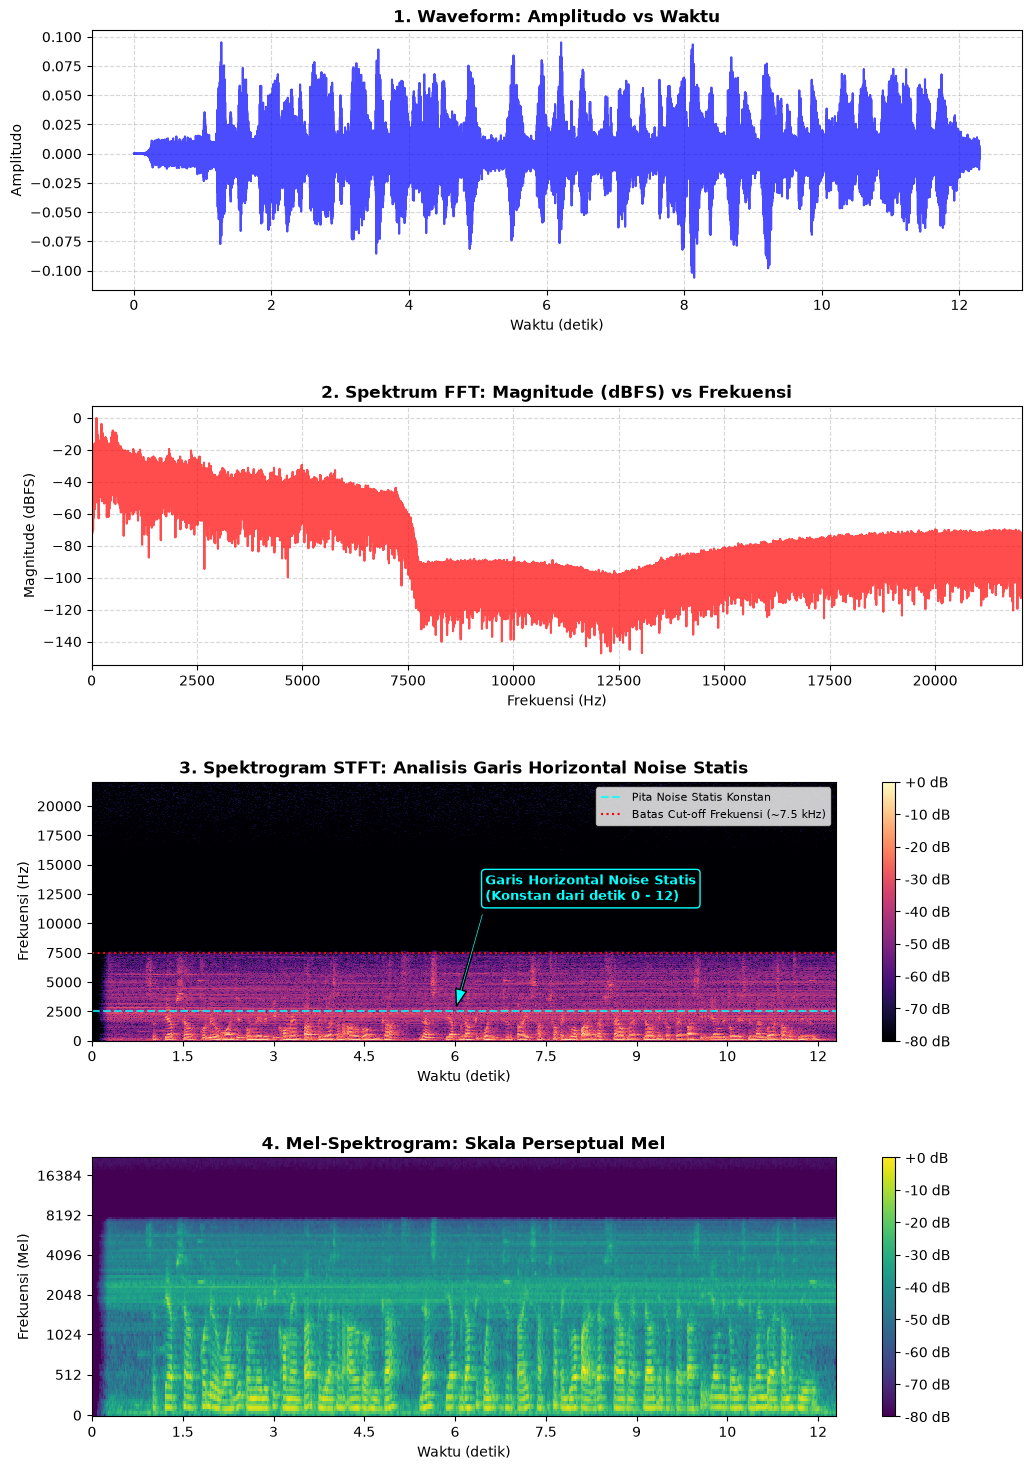

In [30]:
# ==============================================================================
# 2. VISUALISASI AUDIO 4 DIMENSI (FIXED & CLEAN)
# ==============================================================================

# Membuat kanvas utama dengan 4 subplot bertumpuk secara vertikal
fig, axes = plt.subplots(4, 1, figsize=(12, 18))
plt.subplots_adjust(hspace=0.45)

# ------------------------------------------------------------------------------
# --- 2.1 Waveform (Amplitudo vs Waktu) ---
# ------------------------------------------------------------------------------
time_axis = np.linspace(0, duration, num=total_samples)
axes[0].plot(time_axis, y_orig, color='b', alpha=0.7)
axes[0].set_title('1. Waveform: Amplitudo vs Waktu', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Waktu (detik)')
axes[0].set_ylabel('Amplitudo')
axes[0].grid(True, linestyle='--', alpha=0.5)


# ------------------------------------------------------------------------------
# --- 2.2 Spektrum FFT (dBFS Terkalibrasi) ---
# ------------------------------------------------------------------------------
fft_spectrum = np.fft.rfft(y_orig)
freq_axis = np.fft.rfftfreq(total_samples, d=1/fs_orig)

# Konversi magnitude ke skala dBFS (20 log10)
magnitude = np.abs(fft_spectrum)
magnitude_db = 20 * np.log10(magnitude / np.max(magnitude) + 1e-10)

axes[1].plot(freq_axis, magnitude_db, color='r', alpha=0.7)
axes[1].set_title('2. Spektrum FFT: Magnitude (dBFS) vs Frekuensi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frekuensi (Hz)')
axes[1].set_ylabel('Magnitude (dBFS)')
axes[1].set_xlim(0, fs_orig / 2)
axes[1].grid(True, linestyle='--', alpha=0.5)


# ------------------------------------------------------------------------------
# --- 2.3 Spektrogram STFT ---
# ------------------------------------------------------------------------------
n_fft = 2048
hop_length = 512
stft_matrix = librosa.stft(y_orig, n_fft=n_fft, hop_length=hop_length)
stft_db = librosa.amplitude_to_db(np.abs(stft_matrix), ref=np.max)

# Gambar di subplot ke-3 (axes[2])
img_stft = librosa.display.specshow(stft_db, sr=fs_orig, hop_length=hop_length, 
                                    x_axis='time', y_axis='hz', ax=axes[2], cmap='magma')

# Garis horizontal penanda noise statis & cut-off
axes[2].axhline(y=2500, color='cyan', linestyle='--', linewidth=1.5, alpha=0.8, label='Pita Noise Statis Konstan')
axes[2].axhline(y=7500, color='red', linestyle=':', linewidth=1.5, label='Batas Cut-off Frekuensi (~7.5 kHz)')

# Anotasi panah penunjuk
axes[2].annotate('Garis Horizontal Noise Statis\n(Konstan dari detik 0 - 12)', 
                xy=(6, 2500), xytext=(6.5, 12000),
                arrowprops=dict(facecolor='cyan', shrink=0.05, width=1.5, headwidth=8),
                fontsize=9, color='cyan', fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="black", ec="cyan", lw=1))

axes[2].set_title('3. Spektrogram STFT: Analisis Garis Horizontal Noise Statis', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Waktu (detik)', fontsize=10)
axes[2].set_ylabel('Frekuensi (Hz)', fontsize=10)
axes[2].legend(loc='upper right', fontsize=8)
fig.colorbar(img_stft, ax=axes[2], format="%+2.0f dB")


# ------------------------------------------------------------------------------
# --- 2.4 Mel-Spektrogram ---
# ------------------------------------------------------------------------------
mel_spec = librosa.feature.melspectrogram(y=y_orig, sr=fs_orig, n_fft=n_fft, hop_length=hop_length, n_mels=128)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

# Gambar di subplot ke-4 (axes[3])
img_mel = librosa.display.specshow(mel_spec_db, sr=fs_orig, hop_length=hop_length, 
                                   x_axis='time', y_axis='mel', ax=axes[3], cmap='viridis')

axes[3].set_title('4. Mel-Spektrogram: Skala Perseptual Mel', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Waktu (detik)', fontsize=10)
axes[3].set_ylabel('Frekuensi (Mel)', fontsize=10)
fig.colorbar(img_mel, ax=axes[3], format="%+2.0f dB")

# Tampilkan seluruh kanvas
plt.show()

1. Pada grafik waveform, static noise dan suara vocal dapat dibedakan,suara noise static cenderung memiliki wave yang konstan 
    sedangkan vokal lebih dinamiss

2. Pada grafik FFT, Frekuensi Utama yang Sangat Mendominasi: 0Hzhingga 500Hz
   Frekuensi Pendukung Noise static & Vokal: 1.000 Hz hingga 7.500 Hz Pada rentang ini.

3. Formasi vokal manusia terlihat jauh lebih padat, terpisah, dan jelas pada Mel-Spektrogram karena 
    skala ini merepresentasikan cara kerja pendengaran manusia yang bersifat logaritmik, bukan linier seperti pada 
    skala Hertz standar. Telinga manusia memiliki sensitivitas yang jauh lebih tinggi dalam membedakan perubahan 
    frekuensi pada rentang rendah hingga menengah (0 - 4.000Hz), di mana energi utama dan karakteristik 
    artikulasi vokal manusia berkumpul. Pada spektrogram STFT biasa, rentang frekuensi vokal ini dipaksa berdesakan 
    di porsi paling bawah grafik karena skala linier membagi ruang secara merata hingga frekuensi tinggi (8.000 Hz) 
    yang sebenarnya kurang relevan bagi ucapan manusia. Skala Mel secara efektif melakukan proses zoom in dengan 
    memperlebar porsi visual untuk frekuensi rendah-menengah dan mengecilkan area frekuensi tinggi. 
    Akibatnya, pita-pita energi bentuk vokal (formants) yang tadinya menumpuk dapat terurai dengan merekah, 
    kontras, dan tampak lebih padat di atas warna latar belakang derau statis.   
    



--- METADATA SAMPLE RATE RESAMPLING ---
Sample Rate Audio Asli (Original) : 44100 Hz
Sample Rate Skenario A (Naive)    : 8000 Hz (Faktor desimasi M = 5)
Sample Rate Skenario B (Clean)    : 8000 Hz
Batas Frekuensi Nyquist Baru      : 4000.0 Hz



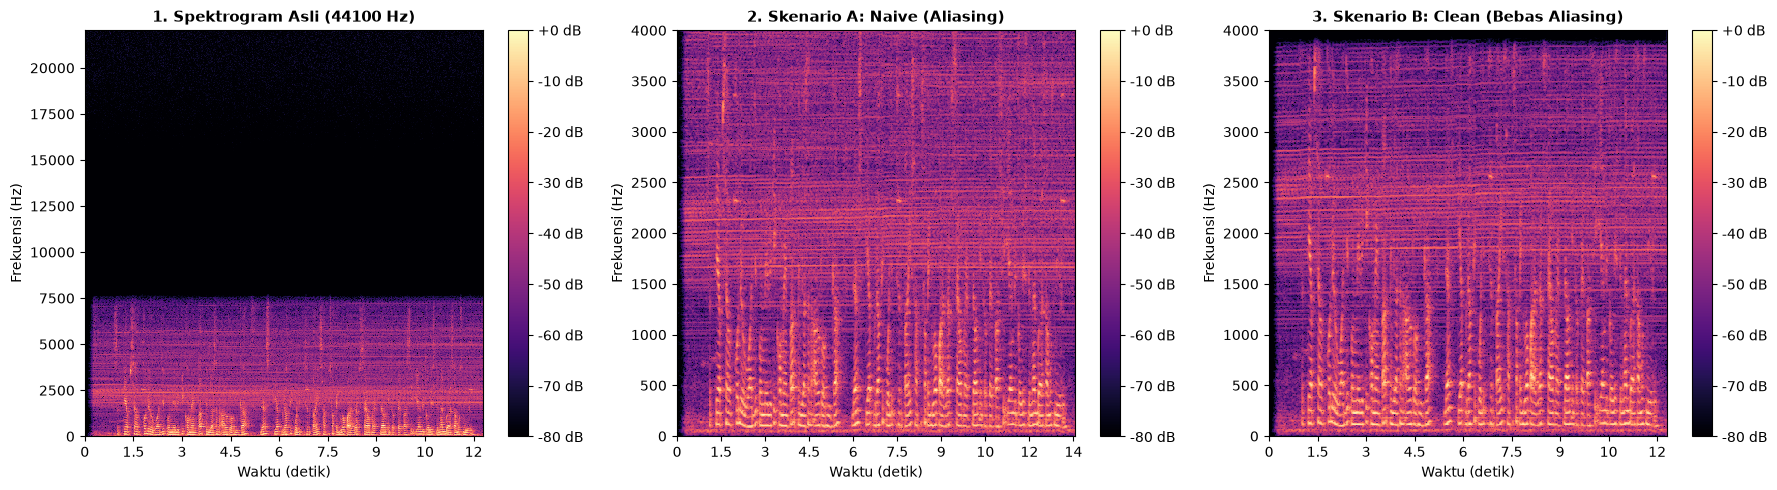

In [31]:
# ==============================================================================
# 3. EKSPERIMEN RESAMPLING & PEMBUKTIAN ALIASING
# ==============================================================================

# Menentukan laju sampel target baru yang lebih rendah (8000 Hz)
fs_target = 8000

# Menhitung rasio pemotongan sampel / faktor desimasi M (misal: 48000 / 8000 = 6)
M = int(fs_orig / fs_target)

# --- Skenario A: Naive Decimation (Tanpa Filter Anti-Aliasing) ---
# Mengambil sampel sinyal secara mentah dengan meloncat setiap M sampel (x[::M]).
# Cara ini mengabaikan batas Nyquist sehingga menyebabkan komponen frekuensi tinggi mengalami aliasing.
y_naive = y_orig[::M]

# --- Skenario B: Resampling Standar (Dengan Filter LPF Anti-Aliasing) ---
# Menerapkan fungsi resampling standar dari librosa.
# Fungsi ini secara otomatis memasang Low-Pass Filter (LPF) anti-aliasing sebelum proses desimasi.
y_clean = librosa.resample(y_orig, orig_sr=fs_orig, target_sr=fs_target)

# ==============================================================================
# MENAMPILKAN OUTPUT SAMPLE RATE MASING-MASING SINYAL
# ==============================================================================
print("--- METADATA SAMPLE RATE RESAMPLING ---")
print(f"Sample Rate Audio Asli (Original) : {fs_orig} Hz")
print(f"Sample Rate Skenario A (Naive)    : {fs_target} Hz (Faktor desimasi M = {M})")
print(f"Sample Rate Skenario B (Clean)    : {fs_target} Hz")
print(f"Batas Frekuensi Nyquist Baru      : {fs_target / 2} Hz\n")

# --- Simpan File Audio Hasil Downsampling ---
wavfile.write('audio_downsampled_naive.wav', fs_target, (y_naive * 32767).astype(np.int16))
wavfile.write('audio_downsampled_clean.wav', fs_target, (y_clean * 32767).astype(np.int16))


# ==============================================================================
# VISUALISASI KOMPARASI 3 SPEKTROGRAM (ORIGINAL vs NAIVE vs CLEAN)
# ==============================================================================
# Membuat kanvas 1 baris, 3 kolom untuk komparasi langsung
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Spektrogram Audio Asli (Original) ---
stft_orig = librosa.stft(y_orig, n_fft=2048, hop_length=512)
db_orig = librosa.amplitude_to_db(np.abs(stft_orig), ref=np.max)
img_orig = librosa.display.specshow(db_orig, sr=fs_orig, hop_length=512, x_axis='time', y_axis='hz', ax=axes[0], cmap='magma')
axes[0].set_title(f'1. Spektrogram Asli ({fs_orig} Hz)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Waktu (detik)')
axes[0].set_ylabel('Frekuensi (Hz)')
fig.colorbar(img_orig, ax=axes[0], format="%+2.0f dB")

# --- 2. Spektrogram Skenario A (Naive Decimation) ---
stft_naive = librosa.stft(y_naive, n_fft=1024, hop_length=256)
db_naive = librosa.amplitude_to_db(np.abs(stft_naive), ref=np.max)
img_a = librosa.display.specshow(db_naive, sr=fs_target, hop_length=256, x_axis='time', y_axis='hz', ax=axes[1], cmap='magma')
axes[1].set_title('2. Skenario A: Naive (Aliasing)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Waktu (detik)')
axes[1].set_ylabel('Frekuensi (Hz)')
fig.colorbar(img_a, ax=axes[1], format="%+2.0f dB")

# --- 3. Spektrogram Skenario B (Clean Resampling) ---
stft_clean = librosa.stft(y_clean, n_fft=1024, hop_length=256)
db_clean = librosa.amplitude_to_db(np.abs(stft_clean), ref=np.max)
img_b = librosa.display.specshow(db_clean, sr=fs_target, hop_length=256, x_axis='time', y_axis='hz', ax=axes[2], cmap='magma')
axes[2].set_title('3. Skenario B: Clean (Bebas Aliasing)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Waktu (detik)')
axes[2].set_ylabel('Frekuensi (Hz)')
fig.colorbar(img_b, ax=axes[2], format="%+2.0f dB")

plt.tight_layout()
plt.show()

Berdasarkan grafik komparasi spektrogram, penurunan laju sampel (downsampling) dari 44.100Hz ke 8.000Hz secara 
otomatis menggeser batas frekuensi Nyquist = f_s/2 dari 22.050Hz menjadi 4.000Hz. 
Pada Skenario A (Naive Decimation), pemotongan sampel secara langsung tanpa Low-Pass Filter (LPF) 
menyebabkan pelanggaran Teorema Nyquist-Shannon. Akibatnya, komponen frekuensi tinggi dari derau 
statis dan vokal asli yang berada pada rentang 4.000Hz - 7.500Hz melipat dan memantul 
balik (folding effect) ke pita frekuensi rendah 0 - 4.000Hz. Hal ini terbukti secara visual 
pada spektrogram Skenario A, di mana area frekuensi 2.000Hz - 4.000Hz tampak jauh lebih terang 
dan padat oleh tumpukan warna ungu-kemerahan buatan, serta memunculkan garis-garis phantom \
derau statis yang mengotori harmonis vokal. Sebaliknya, Skenario B (Clean Resampling) 
berhasil meredam seluruh energi frekuensi di atas 4.000Hz terlebih dahulu menggunakan 
filter anti-aliasing sebelum proses pemotongan sampel. Hasilnya, spektrogram Skenario B 
secara presisi mempertahankan bentuk sinyal asli 0 - 4.000Hz tanpa adanya artefak 
distorsi atau energi palsu, sehingga menjaga kualitas audio tetap alami. 



    

In [8]:
from IPython.display import Audio, display

print("--- 1. Audio Original ---")
display(Audio(y_orig, rate=fs_orig))

print("--- 2. Audio Naive Decimation (Aliasing / Suara Rusak) ---")
display(Audio(y_naive, rate=fs_target))

print("--- 3. Audio Clean Resampling (Bebas Aliasing) ---")
display(Audio(y_clean, rate=fs_target))

--- 1. Audio Original ---


--- 2. Audio Naive Decimation (Aliasing / Suara Rusak) ---


--- 3. Audio Clean Resampling (Bebas Aliasing) ---
